In [1]:
# Import Libraries
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go

# for Bayesian Inference
import pymc as pm 
import arviz as az

g++ not available, if using conda: `conda install gxx`


In [2]:
# Define General + IMPORT DATA

TRADING_DAYS = 252
SYMBOL = 'SPY'

raw = yf.download(SYMBOL, start = '2010-01-01', end='2026-01-01' , auto_adjust = True, progress = False)
price = raw['Close']
if isinstance(price, pd.DataFrame):
    price = price.iloc[:,0]
price = price.dropna().rename(SYMBOL)
price.tail() # check last values verify

Date
2025-12-24    686.730530
2025-12-26    686.660889
2025-12-29    684.213867
2025-12-30    683.378357
2025-12-31    678.315247
Name: SPY, dtype: float64

In [3]:
# Get asset return
asset_return = price.pct_change().fillna(0.0)
px.line(price, title = f'{SYMBOL}: adjusted close').show()

In [4]:
# (A) Create Signal (no look-ahead)
FAST, SLOW = 50,200
COST_BPS =10.0
EXTRA_DELAY_DAYS = 0

fast_ma = price.rolling(FAST , min_periods=FAST).mean()
slow_ma = price.rolling(SLOW , min_periods=SLOW).mean()
raw_signal = (fast_ma > slow_ma).astype(float)
position = raw_signal.shift(1 + EXTRA_DELAY_DAYS).fillna(0.0)\

pd.DataFrame({'price': price, 'fast_ma': fast_ma, 'slow_ma': slow_ma, 'signal': raw_signal, 'position': position}).tail()

,price,fast_ma,slow_ma,signal,position
Date,,,,,
2025-12-24,686.730530,671.386594,617.572875,1.0,1.0
2025-12-26,686.660889,671.925724,618.258863,1.0,1.0
2025-12-29,684.213867,672.505769,618.969240,1.0,1.0
2025-12-30,683.378357,672.994719,619.619447,1.0,1.0
2025-12-31,678.315247,673.245343,620.223003,1.0,1.0


In [5]:
# (B) Net Backtest -
#  note:  assume long strategy where turnover is position weight today - previous

turnover = position.diff().abs().fillna(position.abs())
cost_rate = COST_BPS / 10_000
trading_cost = cost_rate * turnover
gross_return = position * asset_return
net_return = gross_return - trading_cost
equity = (1.0 + net_return).cumprod()
benchmark_equity = (1.0 + asset_return).cumprod()

equity_frame = pd.DataFrame({'strategy (net)': equity, f'{SYMBOL} buy-and-hold': benchmark_equity})
px.line(equity_frame, title= 'A headline backtest - beginning').show()

In [6]:
# (C) Metrics
# Sharpe Ratio = annual return / volatility
# Max Drawdown = max(% drop)

def annualized_returns(returns):
    returns = returns.dropna()
    return(1.0 + returns).prod() ** (TRADING_DAYS / len(returns)) - 1.0

def metrics(returns):
    returns = returns.dropna()
    equity = (1.0 + returns).cumprod()
    daily_vol = returns.std(ddof = 1)
    return{
        'annual_return': annualized_returns(returns),
        'annual_volatility': daily_vol * np.sqrt(TRADING_DAYS),
        'sharpe': returns.mean() / daily_vol * np.sqrt(TRADING_DAYS),
        'max_drawdown': (equity/ equity.cummax() -1 ).min()
    }

pd.Series(metrics(net_return)).map(lambda x: f'{x:.2%}' if abs(x) < 10 else f'{x:.2f}')

annual_return          8.83%
annual_volatility     13.98%
sharpe                67.53%
max_drawdown         -33.72%
dtype: str

In [7]:
# (D) Compile into the engine

from robustness_lab import (
    StrategyConfig, run_moving_average_backtest, parameter_surface, run_stress_test,
    robustness_summary, fit_bayesian_alpha, posterior_summary, posterior_predictive_paths
)

baseline = run_moving_average_backtest(price, StrategyConfig(FAST, SLOW, COST_BPS, EXTRA_DELAY_DAYS))
baseline.metrics

{'total_return': 2.860011477965019,
 'annual_return': 0.08826502902498601,
 'annual_volatility': np.float64(0.1398033026864026),
 'sharpe': 0.6752983122454025,
 'max_drawdown': -0.33717265964796705,
 'observations': 4024.0}

In [8]:
# Testing Parameters ----------------------
# (1) Parameter Surface

surface = parameter_surface(price, range(20, 101, 10), range(100, 321, 20), cost_bps = COST_BPS)
matrix = surface.pivot(index = 'slow_window', columns = 'fast_window', values = 'sharpe').sort_index()
fig = px.imshow(matrix, origin = 'lower', aspect= 'auto', color_continuous_scale= 'Viridis', title = 'Sharpe across nearby MA choices')
fig.update_layout(xaxis_title = 'fast window', yaxis_title = 'slow window')
fig.show()


In [9]:
# (2) Stress Test

scenarios = run_stress_test(price, n_scenarios=250, seed =7)
robustness_summary(scenarios)

px.scatter(
    scenarios, x='cost_bps', y = 'sharpe', color = 'execution_delay_days', 
    hover_data=['fast_window', 'slow_window', 'max_drawdown'],
    title = "Fragility: one point per pre-specified  stress scenario",
).show()



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta, sigma, nu_minus_two]
Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 9 seconds.
There were 678 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


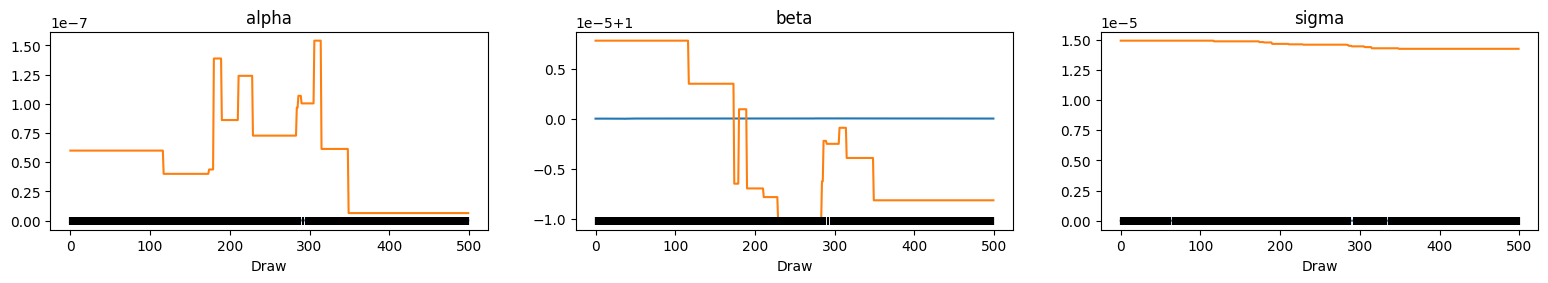

In [10]:
# (3) Bayesian alpha- model

idata = fit_bayesian_alpha(
    baseline.frame['net_return'],
    baseline.frame['asset_return'],
    prior = 'skeptical',
    draws= 500, tune=500, seed =42
)

evidence = posterior = posterior_summary(idata)
evidence

alpha_draws = idata.posterior['alpha'].values.reshape(-1) * TRADING_DAYS

# plot - 
fig = go.Figure(go.Histogram(x=alpha_draws, histnorm='probability density', nbinsx=45, marker_color='#2E74B5'))
fig.add_vline(x=0, line_dash='dash', line_color='#B42318', annotation_text='zero alpha')
fig.update_layout(title='Posterior annualized alpha', xaxis_title='annualized alpha', yaxis_title='density', template='plotly_white')
fig.show()
az.plot_trace(idata, var_names=['alpha', 'beta', 'sigma']);

In [11]:
# PREDICTIVE POSSIBILITIES

paths = posterior_predictive_paths(idata, baseline.frame['asset_return'], horizon =252, n_paths = 300, seed =99)
days = np.arange(1, TRADING_DAYS+1)
low, middle, high = np.quantile(paths, [0.05, 0.50, 0.95], axis=0)
fig = go.Figure()
fig.add_trace(go.Scatter(x=days, y=high, line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=days, y=low, fill='tonexty', fillcolor='rgba(46,116,181,0.18)', line=dict(width=0), name='90% band'))
fig.add_trace(go.Scatter(x=days, y=middle, line=dict(color='#0B2545', width=3), name='median'))
fig.update_layout(title='One-year posterior-predictive equity paths', xaxis_title='future trading days', yaxis_title='equity from $1', template='plotly_white')
fig.show()